# Figure S3 — CoGAPS Patterns vs Cerebellar Cell Types (Spearman correlation)

Reproduction of **Figure S3** from the Mouse Prematurity Insults manuscript.

Built on Kyla Woyshner's published recipe from `cogaps_mouse_folia_n15_res.ipynb`
(Kratimenos Lab — `kratimenoslab/Mouse-Prematurity-Insults/CoGAPS/`, folia-restricted run),
with the cell-type aggregation used in the manuscript figure (8 columns instead of the
6 in the GitHub notebook):

| Column | Composition |
|---|---|
| **GC** | `GC` |
| **PC** | `PC` |
| **MLI** | `MLI 1` + `MLI 1/2` + `MLI 2` + `MLI 3` |
| **Interneuron** | all MLI subtypes + PLI subtypes (broader interneuron umbrella) |
| **Bergmann Glia** | `Bergmann Glia` |
| **PLI** | `PLI 1` + `PLI 2 Putative Lugaro` |
| **Golgi Cells** | `Golgi Cells` |
| **WM** | `WM` |

Same `sns.clustermap` call, same `vlag` colormap, same Spearman correlation, vmin=-1 / vmax=+1.

**Inputs** (in `./data/`):
- `mouse_CB_folia_cogaps_n15_nIterations20k_patterns.csv` — per-spot CoGAPS pattern weights (folia run, 5830 spots × 13 patterns)
- `mouse_CB_meta.csv` — per-spot metadata (uses the `annotations` column)

**Outputs** (next to this notebook):
- `FigS3_celltype_heatmap.pdf`
- `FigS3_celltype_heatmap.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('data')
OUT_DIR  = Path('.')

# Use Arial across all figures (publication consistency)
plt.rcParams['font.family'] = 'Arial'


## Load data
Verbatim load block from Kyla's `cogaps_mouse_folia_n15_res.ipynb`.

In [2]:
meta = pd.read_csv(DATA_DIR / 'mouse_CB_meta.csv', index_col=0)
patterns = pd.read_csv(DATA_DIR / 'mouse_CB_folia_cogaps_n15_nIterations20k_patterns.csv',
                       index_col=0)
n_patterns = patterns.shape[1]

print(f'patterns: {patterns.shape}  (spots x patterns)')
print(f'meta:     {meta.shape}      (spots x columns)')
print(f'n_patterns = {n_patterns}')
print(f"\nannotations (folia spots intersected with meta):")
print(meta.loc[meta.index.intersection(patterns.index), 'annotations'].value_counts())

patterns: (5830, 13)  (spots x patterns)
meta:     (8961, 17)      (spots x columns)
n_patterns = 13

annotations (folia spots intersected with meta):
annotations
GC                       1470
MLI 1/2                  1194
PC                        900
PLI 2 Putative Lugaro     468
Bergmann Glia             448
PLI 1                     408
MLI 1                     290
MLI 2                     219
WM                        213
MLI 3                     177
Golgi Cells                43
Name: count, dtype: int64


## Build the 8-column cell-type indicator matrix

In [3]:
meta_sub = meta.loc[meta.index.intersection(patterns.index)]
a = meta_sub['annotations']

mli_all = ['MLI 1', 'MLI 1/2', 'MLI 2', 'MLI 3']
pli_all = ['PLI 1', 'PLI 2 Putative Lugaro']

ct = pd.DataFrame(index=meta_sub.index)
ct['GC']             = (a == 'GC').astype(int)
ct['PC']             = (a == 'PC').astype(int)
ct['MLI']            = a.isin(mli_all).astype(int)
ct['Interneuron']    = a.isin(mli_all + pli_all).astype(int)
ct['Bergmann Glia']  = (a == 'Bergmann Glia').astype(int)
ct['PLI']            = a.isin(pli_all).astype(int)
ct['Golgi Cells']    = (a == 'Golgi Cells').astype(int)
ct['WM']             = (a == 'WM').astype(int)

ct.sum().to_frame('spots')

,spots
GC,1470
PC,900
MLI,1880
Interneuron,2756
Bergmann Glia,448
PLI,876
Golgi Cells,43
WM,213


## Spearman correlation: patterns × cell types
Same recipe as Kyla's Cell 9, with the 8-column aggregation above:

```python
sns.clustermap(
    patterns.merge(ct, left_index=True, right_index=True)
            .corr('spearman').iloc[:n_patterns, n_patterns:],
    annot=True, cmap=sns.color_palette('vlag', as_cmap=True), vmin=-1, vmax=1)
```

In [4]:
merged = patterns.merge(ct, left_index=True, right_index=True)
corr = merged.corr('spearman').iloc[:n_patterns, n_patterns:]

row_rename = {f'Pattern_{i}': f'M-{i}' for i in range(1, n_patterns + 1)}
corr = corr.rename(index=row_rename)

# Preserve the published column order
corr = corr[['GC', 'PC', 'MLI', 'Interneuron', 'Bergmann Glia', 'PLI', 'Golgi Cells', 'WM']]
corr.round(3)

,GC,PC,MLI,Interneuron,Bergmann Glia,PLI,Golgi Cells,WM
M-1,0.090,0.134,-0.066,-0.032,-0.155,0.042,-0.063,-0.133
M-2,-0.086,0.067,-0.088,-0.058,0.036,0.033,0.049,0.152
M-3,-0.077,0.180,-0.180,-0.078,-0.094,0.127,0.047,0.150
M-4,0.193,0.267,-0.143,-0.242,-0.157,-0.151,-0.080,-0.057
M-5,0.501,0.016,-0.193,-0.275,-0.159,-0.132,-0.101,-0.186
M-6,-0.389,0.216,0.456,0.374,-0.244,-0.074,-0.049,-0.141
M-7,0.037,-0.176,-0.373,-0.106,0.266,0.339,0.008,0.156
M-8,-0.208,0.583,0.106,-0.055,-0.193,-0.215,-0.096,-0.179
M-9,-0.300,-0.074,0.328,0.348,-0.086,0.058,0.024,0.020
M-10,-0.138,0.046,0.084,0.069,0.047,-0.014,-0.061,0.008


Saved: FigS3.pdf
Saved: FigS3.png


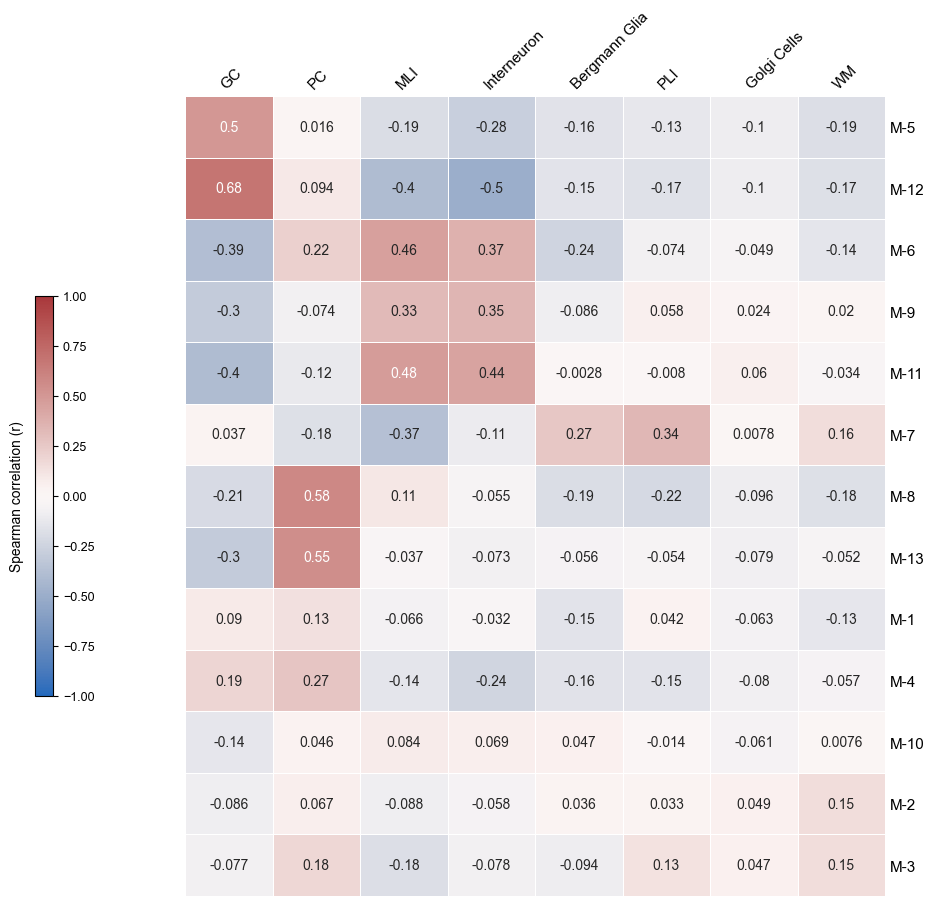

In [5]:
g = sns.clustermap(
    corr,
    annot=True,
    fmt='.2g',
    col_cluster=False,
    cmap=sns.color_palette('vlag', as_cmap=True),
    vmin=-1, vmax=1,
    figsize=(10, 10),
    cbar_pos=None,
    dendrogram_ratio=(0.001, 0.001),
    linewidths=0.4, linecolor='white',
)

g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

# Heatmap placement leaves room for a left-side colorbar
g.ax_heatmap.set_position([0.22, 0.10, 0.70, 0.80])

g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', length=0, labelsize=11)
g.ax_heatmap.tick_params(axis='y', rotation=0, length=0, labelsize=11)

# x labels on top with the manuscript's 45-degree rotation
g.ax_heatmap.xaxis.tick_top()
g.ax_heatmap.xaxis.set_label_position('top')
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor')

# y labels on the right (manuscript style)
g.ax_heatmap.yaxis.tick_right()

# External slim vertical colorbar on the left, label rotated
cbar_ax = g.fig.add_axes([0.07, 0.30, 0.018, 0.40])
cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cbar_ax)
cbar.set_label('Spearman correlation (r)', fontsize=10, rotation=90, labelpad=8)
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params(labelsize=9)

out_pdf = OUT_DIR / 'FigS3.pdf'
out_png = OUT_DIR / 'FigS3.png'
g.savefig(out_pdf)
g.savefig(out_png, dpi=300)
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')
plt.show()

## Row order — sanity check vs published Fig S3
Published Fig S3 order (top → bottom): M-5, M-12, M-6, M-9, M-11, M-7, M-8, M-13, M-1, M-4, M-10, M-2, M-3.

In [6]:
row_order = [corr.index[i] for i in g.dendrogram_row.reordered_ind]
published = ['M-5','M-12','M-6','M-9','M-11','M-7','M-8','M-13','M-1','M-4','M-10','M-2','M-3']
print('My row order (top -> bottom):')
print(row_order)
print('\nPublished Fig S3 order:')
print(published)
print('\nMatch:', row_order == published)

My row order (top -> bottom):
['M-5', 'M-12', 'M-6', 'M-9', 'M-11', 'M-7', 'M-8', 'M-13', 'M-1', 'M-4', 'M-10', 'M-2', 'M-3']

Published Fig S3 order:
['M-5', 'M-12', 'M-6', 'M-9', 'M-11', 'M-7', 'M-8', 'M-13', 'M-1', 'M-4', 'M-10', 'M-2', 'M-3']

Match: True
